# Predicting Diabetes Status with 7 Key CDC Features

This notebook predicts whether a survey respondent is in the `Diabetes_binary` positive class using only the top 7 features from the full-feature SHAP summary.

The target is:

- `0`: no diabetes
- `1`: prediabetes or diabetes

In [1]:
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# 1. Data Loading

The dataset is loaded directly from the UCI Machine Learning Repository using `ucimlrepo`.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [6]:
cdc_diabetes = fetch_ucirepo(id=891)

X_raw = cdc_diabetes.data.features.copy()
X_raw = X_raw[top_features]
y_raw = cdc_diabetes.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)
df.sample(5)

,GenHlth,Age,BMI,HighBP,HighChol,Sex,Income,Diabetes_binary
29700,1,8,19,0,0,1,4,0
185783,1,6,27,0,0,1,8,0
110816,2,9,36,1,1,1,8,0
220015,4,10,31,1,1,1,8,0
64875,5,13,23,1,0,1,8,0


In [7]:
target_col = "Diabetes_binary"
print(f"Rows: {df.shape[0]:,}")

Rows: 253,680


In [8]:
target_distribution = (
    df[target_col]
    .value_counts()
    .rename(index={0: "No diabetes", 1: "Prediabetes/diabetes"})
    .to_frame("count")
)
target_distribution["percentage"] = (target_distribution["count"] / len(df) * 100).round(2)
target_distribution

,count,percentage
Diabetes_binary,,
No diabetes,218334,86.07
Prediabetes/diabetes,35346,13.93


# 2. Exploratory Data Analysis

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
GenHlth,253680.0,2.511392,1.068477,1.0,2.0,2.0,3.0,5.0
Age,253680.0,8.032119,3.054220,1.0,6.0,8.0,10.0,13.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
Sex,253680.0,0.440342,0.496429,0.0,0.0,0.0,1.0,1.0
Income,253680.0,6.053875,2.071148,1.0,5.0,7.0,8.0,8.0
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0


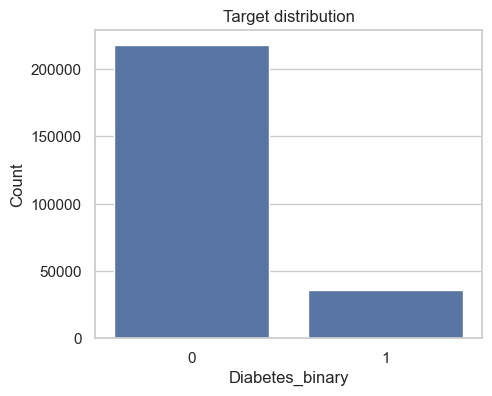

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=target_col)
plt.title("Target distribution")
plt.xlabel("Diabetes_binary")
plt.ylabel("Count")
plt.show()

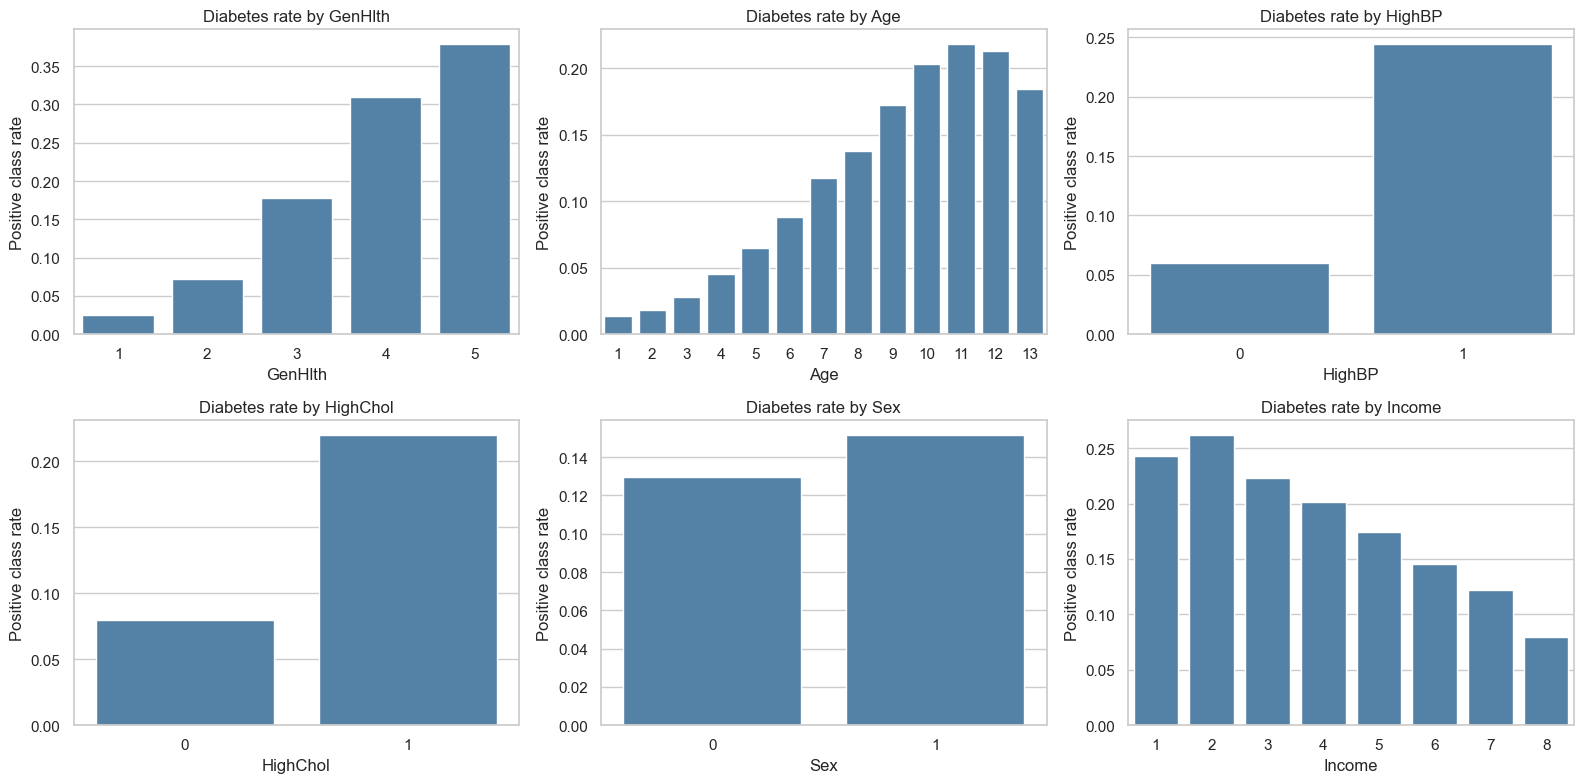

In [13]:
features_to_plot = ["GenHlth", "Age", "HighBP", "HighChol", "Sex", "Income"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, feature in zip(axes.ravel(), features_to_plot):
    rate_df = df.groupby(feature)[target_col].mean().reset_index()
    sns.barplot(data=rate_df, x=feature, y=target_col, ax=ax, color="steelblue")
    ax.set_title(f"Diabetes rate by {feature}")
    ax.set_ylabel("Positive class rate")

plt.tight_layout()
plt.show()

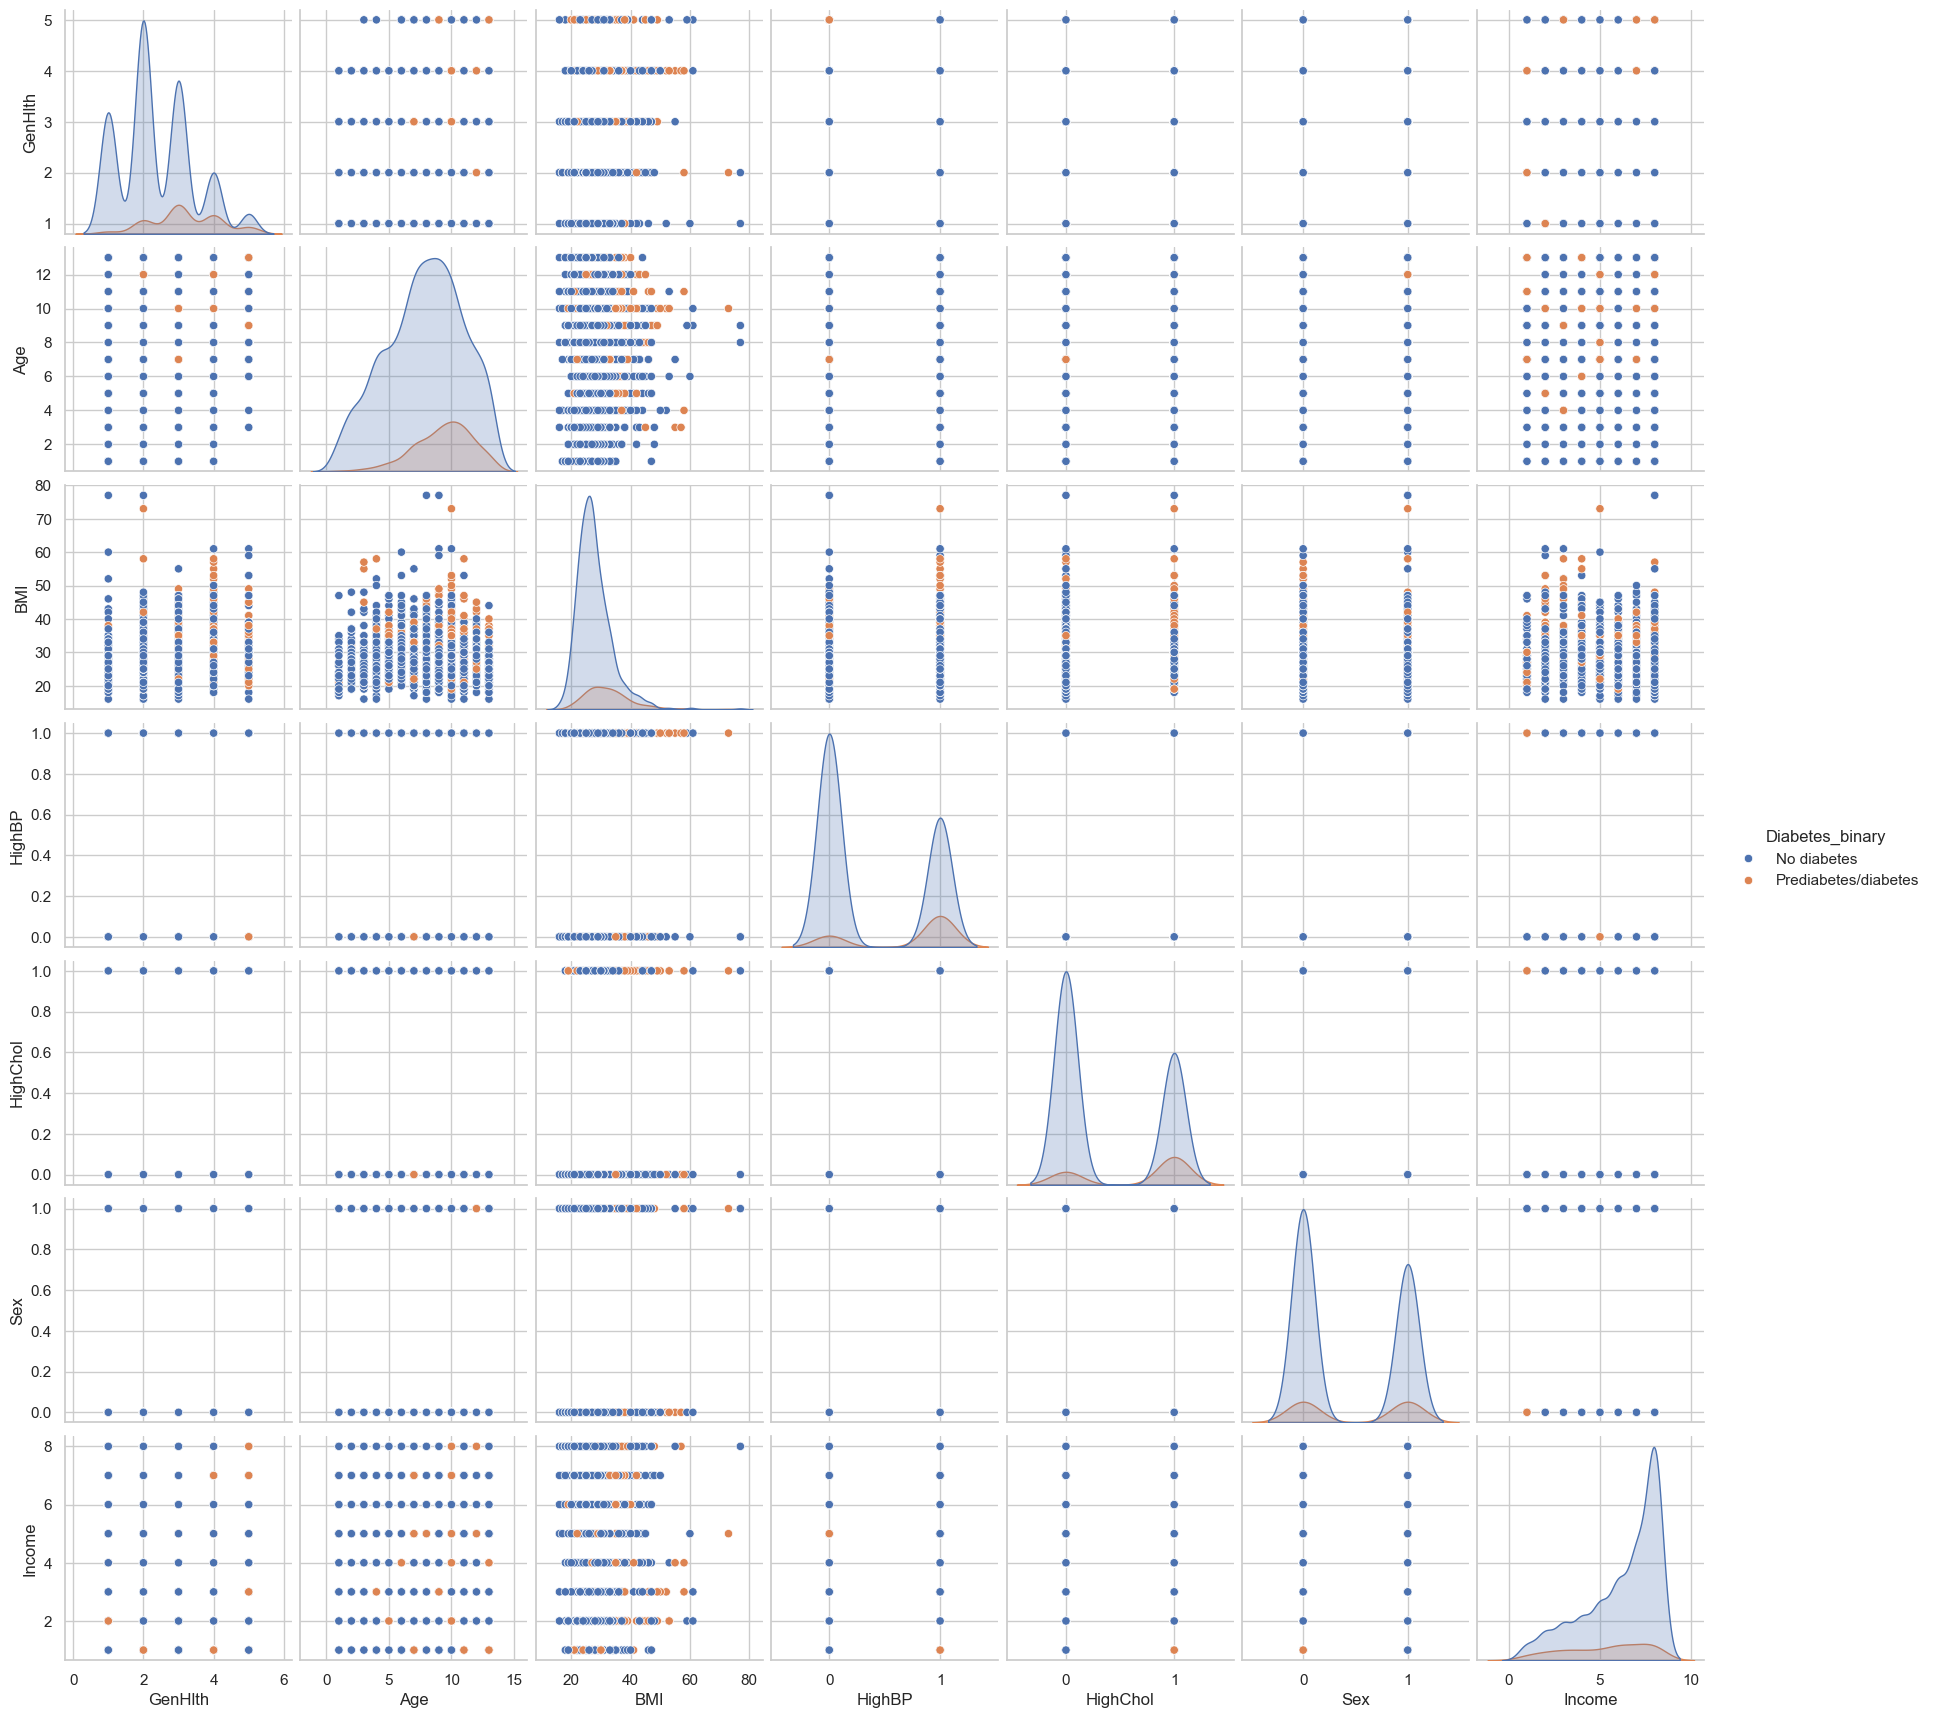

In [14]:
pairplot_sample = df[top_features + [target_col]].sample(
    n=min(2_000, len(df)),
    random_state=RANDOM_STATE,
).copy()
pairplot_sample[target_col] = pairplot_sample[target_col].map(
    {0: "No diabetes", 1: "Prediabetes/diabetes"}
)

sns.pairplot(pairplot_sample, hue=target_col)
plt.show()

#### EDA notes

- The positive class is much smaller than the negative class, so accuracy alone can be misleading.
- The selected predictors include health status, age, BMI, blood pressure, cholesterol, sex, and income.
- The pairplot shows overlap between classes, so this is a risk-ranking problem rather than a clean separation problem.
- `Sex`, `Age`, and `Income` should be interpreted carefully because they can reflect demographic and structural differences.

# 3. Train/Test Split

The split is stratified so the positive-class rate stays similar in the training and test sets.

In [15]:
from sklearn.model_selection import train_test_split

X = df[top_features].copy()
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("Training positive-class rate:", round(y_train.mean(), 4))
print("Test positive-class rate:", round(y_test.mean(), 4))

Training set: (202944, 7)
Test set: (50736, 7)
Training positive-class rate: 0.1393
Test positive-class rate: 0.1393


# 4. Preprocessing

The features are already numeric. We scale the continuous and ordinal fields so logistic regression behaves well. The binary fields are passed through unchanged.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

continuous_features = ["BMI"]
ordinal_features = ["GenHlth", "Age", "Income"]
binary_features = ["HighBP", "HighChol", "Sex"]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", StandardScaler(), continuous_features + ordinal_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

# 5. Modeling

This simplified notebook compares three models:

- Logistic Regression as an interpretable baseline
- Random Forest as a nonlinear tree model
- LightGBM as the stronger boosted-tree model from the full notebook

All three use class weighting to account for the imbalanced target.

In [17]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_predictions(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_score),
        "Average Precision": average_precision_score(y_true, y_score),
    }


majority_class = y_train.mode()[0]
y_baseline_pred = np.full(y_test.shape, majority_class)
y_baseline_score = np.full(y_test.shape, y_train.mean(), dtype=float)

pd.DataFrame(
    [evaluate_predictions(y_test, y_baseline_pred, y_baseline_score)],
    index=["Majority class baseline"],
)

,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
Majority class baseline,0.860671,0.0,0.0,0.0,0.5,0.139329


In [18]:
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model_candidates = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
}

trained_models = {}
model_results = []

for model_name, model in model_candidates.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]

    row = {"Model": model_name}
    row.update(evaluate_predictions(y_test, y_pred, y_score))
    model_results.append(row)

results_df = (
    pd.DataFrame(model_results)
    .sort_values(["Average Precision", "ROC AUC", "F1"], ascending=False)
    .reset_index(drop=True)
)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
0,LightGBM,0.711822,0.299042,0.794879,0.434588,0.821619,0.413586
1,Random Forest,0.723549,0.305486,0.772811,0.437881,0.820136,0.412346
2,Logistic Regression,0.725225,0.305193,0.761494,0.435747,0.815446,0.385998


In [19]:
best_model_name = results_df.loc[0, "Model"]
best_pipeline = trained_models[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
y_score_best = best_pipeline.predict_proba(X_test)[:, 1]

print(f"Selected model: {best_model_name}")
pd.DataFrame(
    [evaluate_predictions(y_test, y_pred_best, y_score_best)],
    index=[best_model_name],
)

Selected model: LightGBM


,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision
LightGBM,0.711822,0.299042,0.794879,0.434588,0.821619,0.413586


# 6. Evaluation

The confusion matrix, ROC curve, and precision-recall curve give a fuller picture than one metric alone.

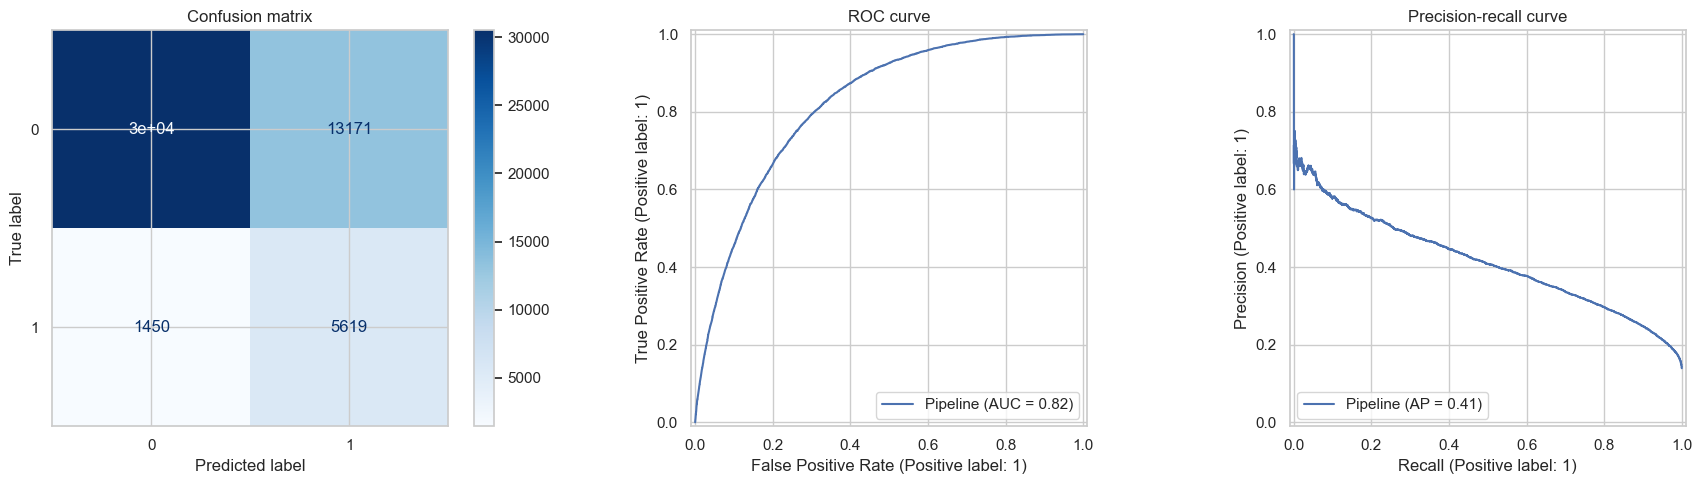

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC curve")

PrecisionRecallDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[2])
axes[2].set_title("Precision-recall curve")

plt.tight_layout()
plt.show()

# 7. Model Interpretation

We use two simple interpretation tools:

- Permutation importance to rank which features affect test performance most
- SHAP to show how feature values push predictions up or down

In [21]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": top_features,
            "importance_mean": importance_result.importances_mean,
            "importance_std": importance_result.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
importance_df

,feature,importance_mean,importance_std
0,GenHlth,0.087103,0.002212
1,BMI,0.086736,0.001897
2,Age,0.043897,0.002075
3,HighBP,0.034147,0.002482
4,HighChol,0.030184,0.001150
5,Sex,0.006044,0.000916
6,Income,0.005900,0.000735


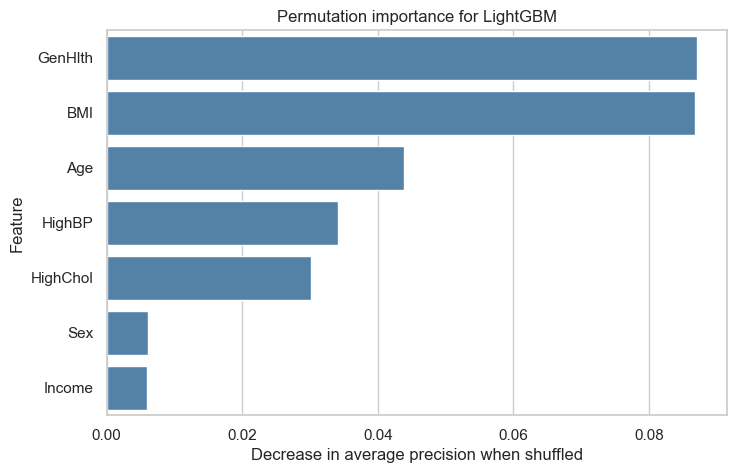

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="steelblue")
plt.title(f"Permutation importance for {best_model_name}")
plt.xlabel("Decrease in average precision when shuffled")
plt.ylabel("Feature")
plt.show()

In [23]:
import shap

SHAP_SAMPLE_SIZE = 500
SHAP_BACKGROUND_SIZE = 50

X_shap = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
shap_background = X_train.sample(
    n=min(SHAP_BACKGROUND_SIZE, len(X_train)),
    random_state=RANDOM_STATE,
)


def predict_positive_class(data):
    data_df = pd.DataFrame(data, columns=top_features)
    return best_pipeline.predict_proba(data_df)[:, 1]


shap_explainer = shap.Explainer(
    predict_positive_class,
    shap_background,
    algorithm="permutation",
)
shap_values = shap_explainer(
    X_shap,
    max_evals=2 * len(top_features) + 1,
)

shap_importance_df = (
    pd.DataFrame(
        {
            "feature": top_features,
            "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_importance_df

,feature,mean_abs_shap
0,GenHlth,0.110682
1,Age,0.078444
2,BMI,0.077666
3,HighBP,0.066456
4,HighChol,0.048546
5,Sex,0.027711
6,Income,0.026308


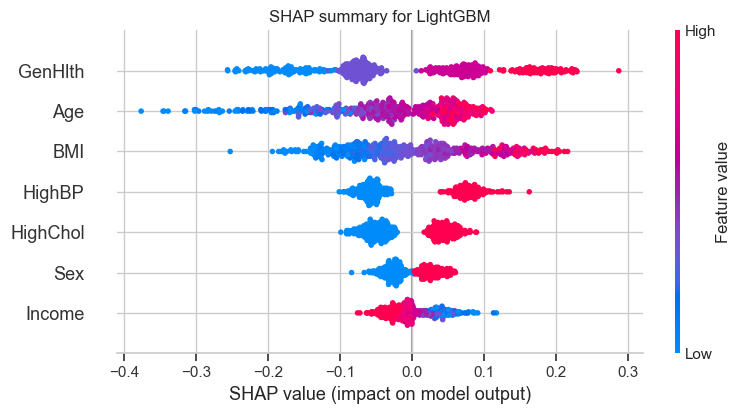

In [24]:
shap.plots.beeswarm(shap_values, max_display=len(top_features), show=False)
plt.title(f"SHAP summary for {best_model_name}")
plt.tight_layout()
plt.show()

#### Interpretation notes

Features near the top of the permutation and SHAP tables have the largest influence in this reduced model.

In the SHAP plot, points to the right increase the predicted probability of prediabetes/diabetes, while points to the left decrease it. Red points are higher feature values and blue points are lower feature values.

These are model explanations, not causal claims. This is especially important for `Sex` and `Income`, which can reflect social, diagnostic, and healthcare-access patterns.

# 8. Save Model

The saved model and metrics use `top7` in the filename so they do not overwrite the full-feature notebook outputs.

In [25]:
from pathlib import Path
import json
import joblib

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "cdc_diabetes_top7_best_model.joblib"
metrics_path = models_dir / "cdc_diabetes_top7_model_metrics.json"

joblib.dump(best_pipeline, model_path)

model_metrics = {
    "selected_model": best_model_name,
    "feature_set": top_features,
    **evaluate_predictions(y_test, y_pred_best, y_score_best),
}

metrics_path.write_text(json.dumps(model_metrics, indent=2))

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")

Saved model to: models/cdc_diabetes_top7_best_model.joblib
Saved metrics to: models/cdc_diabetes_top7_model_metrics.json
